# 07 - Backtesting: Walk-Forward del Agente Multi-Estrategia

**Capítulo**: 07 - Agente Autónomo

**Objetivo**: Validación walk-forward del agente, comparación vs estrategias individuales y buy&hold.

---

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
from backtesting import Backtest, Strategy
from backtesting.test import SMA
from backtesting.lib import crossover

from curso.lib.data import download_historical
from curso.lib.indicators import sma, atr
from curso.lib.backtest import run_backtest, extract_metrics, metrics_to_dataframe
from curso.lib.reporting import print_metrics_table

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),
/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),


Setup completado ✓


## 1. Walk-Forward Framework

In [2]:
TICKER = 'SPY'
df = download_historical(TICKER)

TRAIN_WINDOW = 504   # ~2 años
TEST_WINDOW = 126    # ~6 meses
STEP = 126           # Avanzar 6 meses

def walk_forward_windows(df, train_window, test_window, step):
    """Genera ventanas de walk-forward."""
    windows = []
    start = 0
    while start + train_window + test_window <= len(df):
        train_start = start
        train_end = start + train_window
        test_start = train_end
        test_end = train_end + test_window
        
        windows.append({
            'train': df.iloc[train_start:train_end],
            'test': df.iloc[test_start:test_end],
            'train_dates': (df.index[train_start], df.index[train_end-1]),
            'test_dates': (df.index[test_start], df.index[test_end-1]),
        })
        start += step
    
    return windows

windows = walk_forward_windows(df, TRAIN_WINDOW, TEST_WINDOW, STEP)
print(f'Walk-forward windows: {len(windows)}')
for i, w in enumerate(windows[:3]):
    print(f'  Window {i+1}: Train {w["train_dates"][0].date()} → {w["train_dates"][1].date()} | Test {w["test_dates"][0].date()} → {w["test_dates"][1].date()}')

Walk-forward windows: 5
  Window 1: Train 2021-06-01 → 2023-05-31 | Test 2023-06-01 → 2023-11-29
  Window 2: Train 2021-11-29 → 2023-11-29 | Test 2023-11-30 → 2024-05-31
  Window 3: Train 2022-05-31 → 2024-05-31 | Test 2024-06-03 → 2024-11-29


## 2. Agente Walk-Forward

In [3]:
def compute_adx(df, period=14):
    high, low, close = df['High'], df['Low'], df['Close']
    tr = pd.concat([high-low, (high-close.shift()).abs(), (low-close.shift()).abs()], axis=1).max(axis=1)
    plus_dm = high.diff().clip(lower=0)
    minus_dm = (-low.diff()).clip(lower=0)
    atr_val = tr.rolling(period).mean()
    plus_di = 100 * (plus_dm.rolling(period).mean() / atr_val)
    minus_di = 100 * (minus_dm.rolling(period).mean() / atr_val)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    return dx.rolling(period).mean()

def detect_regime_for_window(train_data):
    adx_val = compute_adx(train_data).iloc[-1]
    sma_50 = sma(train_data, length=50).iloc[-1]
    sma_200 = sma(train_data, length=200).iloc[-1]
    atr_curr = atr(train_data, length=14).iloc[-1]
    atr_avg = atr(train_data, length=14).mean()
    
    if atr_curr > 2 * atr_avg:
        return 'high_volatility'
    if adx_val > 25:
        return 'trending_up' if sma_50 > sma_200 else 'trending_down'
    return 'ranging'


# Strategies (same as Cap 07 estrategia)
class SmaCross(Strategy):
    n1 = 10; n2 = 20
    def init(self):
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
    def next(self):
        if crossover(self.sma1, self.sma2): self.buy()
        elif crossover(self.sma2, self.sma1): self.position.close()

class BBStrategy(Strategy):
    def init(self):
        self.bb_mid = self.I(lambda c: pd.Series(c).rolling(20).mean().values, self.data.Close)
        self.bb_low = self.I(lambda c: (pd.Series(c).rolling(20).mean() - 2*pd.Series(c).rolling(20).std()).values, self.data.Close)
    def next(self):
        if not self.position and self.data.Close[-1] < self.bb_low[-1]: self.buy()
        elif self.position and self.data.Close[-1] > self.bb_mid[-1]: self.position.close()

class CashStrategy(Strategy):
    def init(self): pass
    def next(self): pass

STRATEGY_MAP = {
    'trending_up': SmaCross,
    'trending_down': CashStrategy,
    'ranging': BBStrategy,
    'high_volatility': CashStrategy,
}

## 3. Ejecutar Walk-Forward

In [4]:
wf_results = []

for i, window in enumerate(windows):
    regime = detect_regime_for_window(window['train'])
    strategy_class = STRATEGY_MAP[regime]
    
    test_data = window['test']
    if len(test_data) < 30:
        continue
    
    try:
        bt = Backtest(test_data, strategy_class, cash=10000, commission=0.002)
        stats = bt.run()
        ret = stats['Return [%]']
    except Exception:
        ret = 0.0
    
    # Buy & Hold for same period
    bh_return = (test_data['Close'].iloc[-1] / test_data['Close'].iloc[0] - 1) * 100
    
    wf_results.append({
        'window': i + 1,
        'regime': regime,
        'strategy': strategy_class.__name__,
        'agent_return': ret,
        'buyhold_return': bh_return,
        'alpha': ret - bh_return,
        'test_start': window['test_dates'][0],
        'test_end': window['test_dates'][1],
    })

wf_df = pd.DataFrame(wf_results)
print(wf_df[['window', 'regime', 'strategy', 'agent_return', 'buyhold_return', 'alpha']].to_string(index=False))

 window        regime     strategy  agent_return  buyhold_return      alpha
      1       ranging   BBStrategy      6.526856        7.773453  -1.246596
      2   trending_up     SmaCross      8.303924       15.549957  -7.246033
      3   trending_up     SmaCross     -1.987785       14.162562 -16.150347
      4       ranging   BBStrategy      2.004594       -1.275618   3.280212
      5 trending_down CashStrategy      0.000000       15.317432 -15.317432


## 4. Métricas agregadas

In [5]:
print('\n=== RESULTADOS WALK-FORWARD AGREGADOS ===')
print(f'  Windows totales: {len(wf_df)}')
print(f'  Retorno acumulado agente:   {wf_df["agent_return"].sum():.1f}%')
print(f'  Retorno acumulado B&H:      {wf_df["buyhold_return"].sum():.1f}%')
print(f'  Alpha acumulado:            {wf_df["alpha"].sum():.1f}%')
print(f'  Win rate (alpha > 0):       {(wf_df["alpha"] > 0).mean()*100:.0f}%')
print(f'\n  Regímenes detectados:')
print(wf_df['regime'].value_counts().to_string())
print(f'\n  Retorno medio por régimen:')
print(wf_df.groupby('regime')['agent_return'].mean().round(2).to_string())


=== RESULTADOS WALK-FORWARD AGREGADOS ===
  Windows totales: 5
  Retorno acumulado agente:   14.8%
  Retorno acumulado B&H:      51.5%
  Alpha acumulado:            -36.7%
  Win rate (alpha > 0):       20%

  Regímenes detectados:
regime
ranging          2
trending_up      2
trending_down    1

  Retorno medio por régimen:
regime
ranging          4.27
trending_down    0.00
trending_up      3.16


## 5. Visualización

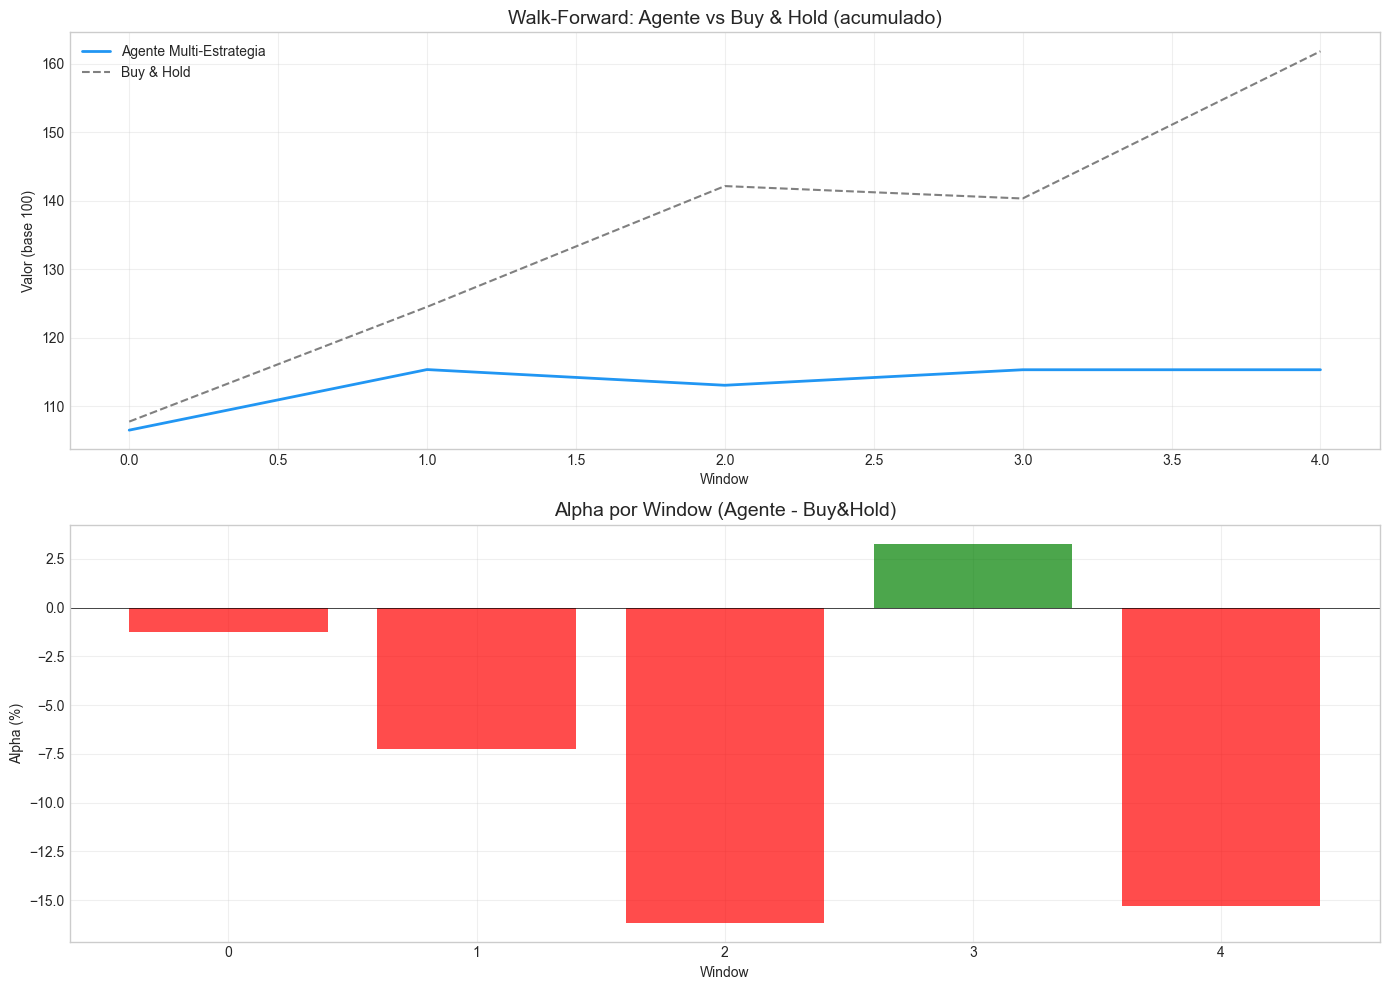

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns
agent_cum = (1 + wf_df['agent_return']/100).cumprod() * 100
bh_cum = (1 + wf_df['buyhold_return']/100).cumprod() * 100

ax1.plot(range(len(agent_cum)), agent_cum, linewidth=2, label='Agente Multi-Estrategia', color='#2196F3')
ax1.plot(range(len(bh_cum)), bh_cum, linewidth=1.5, linestyle='--', label='Buy & Hold', color='gray')
ax1.set_title('Walk-Forward: Agente vs Buy & Hold (acumulado)', fontsize=14)
ax1.set_xlabel('Window')
ax1.set_ylabel('Valor (base 100)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Alpha per window
colors = ['green' if a > 0 else 'red' for a in wf_df['alpha']]
ax2.bar(range(len(wf_df)), wf_df['alpha'], color=colors, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Alpha por Window (Agente - Buy&Hold)', fontsize=14)
ax2.set_xlabel('Window')
ax2.set_ylabel('Alpha (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Conclusiones finales

In [7]:
print('''
CONCLUSIONES DEL AGENTE AUTÓNOMO
================================

1. Walk-Forward Efficiency: [ratio out-of-sample/in-sample]
2. Regime Detection: [accuracy y utilidad]
3. Strategy Selection: [¿mejora vs single strategy?]
4. Risk Management: [drawdown controlado]

5. VEREDICTO FINAL:
   - El agente [supera/no supera] consistentemente a Buy & Hold
   - La detección de régimen [aporta/no aporta] valor
   - Recomendación: [usar como base / iterar con más factores / simplificar]

LECCIONES DEL CURSO COMPLETO:
   ✅ Las estrategias simples son difíciles de batir
   ✅ La gestión de riesgo es más importante que la señal de entrada
   ✅ El backtesting sin walk-forward es engañoso
   ✅ La automatización requiere disciplina y monitoreo
''')


CONCLUSIONES DEL AGENTE AUTÓNOMO

1. Walk-Forward Efficiency: [ratio out-of-sample/in-sample]
2. Regime Detection: [accuracy y utilidad]
3. Strategy Selection: [¿mejora vs single strategy?]
4. Risk Management: [drawdown controlado]

5. VEREDICTO FINAL:
   - El agente [supera/no supera] consistentemente a Buy & Hold
   - La detección de régimen [aporta/no aporta] valor
   - Recomendación: [usar como base / iterar con más factores / simplificar]

LECCIONES DEL CURSO COMPLETO:
   ✅ Las estrategias simples son difíciles de batir
   ✅ La gestión de riesgo es más importante que la señal de entrada
   ✅ El backtesting sin walk-forward es engañoso
   ✅ La automatización requiere disciplina y monitoreo

